## Visualisation des données

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from src.data.load_data import load_features

gdf_features = load_features()

In [3]:
gdf_features.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 229940 entries, 0 to 229939
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   code_commune     229940 non-null  str     
 1   annee            229940 non-null  int32   
 2   type_risque      229940 non-null  str     
 3   nb_catastrophes  229940 non-null  int32   
 4   geometry         229940 non-null  geometry
dtypes: geometry(1), int32(2), str(2)
memory usage: 7.0 MB


In [4]:
gdf_features.sort_values("annee").head(15)

,code_commune,annee,type_risque,nb_catastrophes,geometry
181594,71155,1982,tempete,1,"POLYGON ((3.7041 46.747, 3.709 46.7481, 3.7144..."
181593,71155,1982,neige_grele,1,"POLYGON ((3.7041 46.747, 3.709 46.7481, 3.7144..."
181592,71155,1982,inondation,2,"POLYGON ((3.7041 46.747, 3.709 46.7481, 3.7144..."
66,01025,1982,inondation,1,"POLYGON ((4.9919 46.2911, 4.9861 46.291, 4.985..."
56,01023,1982,inondation,1,"POLYGON ((4.8763 46.3695, 4.8746 46.369, 4.869..."
130347,54216,1982,inondation,1,"POLYGON ((6.3806 48.4541, 6.3798 48.4542, 6.37..."
30317,15167,1982,tempete,1,"POLYGON ((2.2206 44.7743, 2.2178 44.7752, 2.21..."
30316,15167,1982,inondation,1,"POLYGON ((2.2206 44.7743, 2.2178 44.7752, 2.21..."
30313,15166,1982,tempete,1,"POLYGON ((2.2014 44.8368, 2.2004 44.8384, 2.19..."
30312,15166,1982,inondation,1,"POLYGON ((2.2014 44.8368, 2.2004 44.8384, 2.19..."


In [ ]:
from src.data.load_data import load_merged
from src.visualizations.maps import plot_france_communes_risk_count
import matplotlib.pyplot as plt

# Charger les données
gdf = load_merged()

# Voir les valeurs possibles du risque
print(gdf["type_risque"].dropna().unique())

# Exemple (remplace par une valeur exacte affichée)
fig, ax, france_map = plot_france_communes_risk_count(
    merged_gdf=gdf,
    year=2021,
    hazard="inondation",   # ⚠️ doit correspondre exactement à une valeur
    metro_only=True
)

plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_france_regions_with_bars(
    events_gdf: gpd.GeoDataFrame,
    regions_gdf: gpd.GeoDataFrame,
    year: int,
    hazard: str,
    date_col: str = "date_debut",
    hazard_col: str = "type_risque",
    event_region_col: str = "code_region",
    map_region_col: str = "code_region",
    region_label_col: str | None = None,
    figsize: tuple = (12, 12),
    cmap: str = "Greys",
    metro_only: bool = True,
    annotate: bool = False
):
    """
    Affiche une carte des régions de France avec contours visibles
    et un bâton vertical par région représentant le nombre d'occurrences
    d'un aléa pour une année donnée.

    Paramètres
    ----------
    events_gdf : GeoDataFrame
        Base des événements.
    regions_gdf : GeoDataFrame
        Fond de carte des régions.
    year : int
        Année sélectionnée.
    hazard : str
        Aléa sélectionné.
    date_col : str
        Colonne date dans events_gdf.
    hazard_col : str
        Colonne aléa dans events_gdf.
    event_region_col : str
        Colonne région dans events_gdf.
    map_region_col : str
        Colonne région dans regions_gdf.
    region_label_col : str | None
        Colonne nom de région pour affichage.
    figsize : tuple
        Taille de la figure.
    cmap : str
        Palette pour le fond de carte.
    metro_only : bool
        Si True, garde seulement la France métropolitaine.
    annotate : bool
        Si True, écrit la valeur au-dessus de chaque bâton.

    Retour
    ------
    fig, ax, plot_gdf
    """

    # Vérifications
    required_event_cols = [date_col, hazard_col, event_region_col]
    missing_event = [c for c in required_event_cols if c not in events_gdf.columns]
    if missing_event:
        raise ValueError(f"Colonnes manquantes dans events_gdf : {missing_event}")

    if map_region_col not in regions_gdf.columns:
        raise ValueError(f"Colonne absente dans regions_gdf : {map_region_col}")

    if "geometry" not in regions_gdf.columns:
        raise ValueError("La colonne 'geometry' est absente de regions_gdf.")

    events = events_gdf.copy()
    regions = regions_gdf.copy()

    # Harmonisation minimale des clés
    events[event_region_col] = events[event_region_col].astype(str).str.strip()
    regions[map_region_col] = regions[map_region_col].astype(str).str.strip()

    # Date -> année
    events[date_col] = pd.to_datetime(events[date_col], errors="coerce")
    events["_year"] = events[date_col].dt.year

    # Filtrage
    filtered = events[
        (events["_year"] == year) &
        (events[hazard_col] == hazard)
    ].copy()

    # Agrégation par région
    counts = (
        filtered.groupby(event_region_col)
        .size()
        .reset_index(name="nb_occurrences")
    )

    # Jointure sur le fond de carte régional
    plot_gdf = regions.merge(
        counts,
        left_on=map_region_col,
        right_on=event_region_col,
        how="left"
    )

    plot_gdf["nb_occurrences"] = plot_gdf["nb_occurrences"].fillna(0)

    if plot_gdf.crs is None:
        raise ValueError("Le CRS de regions_gdf est manquant.")

    plot_gdf = plot_gdf.to_crs(epsg=4326)

    # Métropole seulement
    if metro_only:
        plot_gdf = plot_gdf.cx[-6:10, 41:52]

    # Centroïdes pour placer les bâtons
    centroids = plot_gdf.geometry.centroid
    plot_gdf["_x"] = centroids.x
    plot_gdf["_y"] = centroids.y

    # Figure
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Fond de carte régional
    plot_gdf.plot(
        ax=ax,
        color="#f2f2f2",
        edgecolor="black",
        linewidth=1.0
    )

    # Échelle des bâtons
    max_count = plot_gdf["nb_occurrences"].max()
    if max_count > 0:
        bar_max_height = 1.8  # hauteur max en degrés approx, visuel
        plot_gdf["_bar_height"] = (plot_gdf["nb_occurrences"] / max_count) * bar_max_height
    else:
        plot_gdf["_bar_height"] = 0

    # Tracer les bâtons
    for _, row in plot_gdf.iterrows():
        x = row["_x"]
        y = row["_y"]
        h = row["_bar_height"]

        ax.vlines(
            x=x,
            ymin=y,
            ymax=y + h,
            color="darkred",
            linewidth=3
        )

        ax.plot(x, y + h, marker="o", markersize=4, color="darkred")

        if annotate and row["nb_occurrences"] > 0:
            ax.text(
                x,
                y + h + 0.12,
                f"{int(row['nb_occurrences'])}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    # Labels des régions si demandé
    if region_label_col is not None and region_label_col in plot_gdf.columns:
        for _, row in plot_gdf.iterrows():
            ax.text(
                row["_x"],
                row["_y"] - 0.15,
                str(row[region_label_col]),
                ha="center",
                va="top",
                fontsize=7
            )

    zone_label = "France métropolitaine" if metro_only else "France"
    ax.set_title(
        f"Occurrences de l'aléa '{hazard}' par région en {year}\n{zone_label}",
        fontsize=13
    )
    ax.axis("off")

    # Légende simple
    custom_line = Line2D([0], [0], color="darkred", lw=3)
    ax.legend([custom_line], ["Nombre d'occurrences"], loc="lower left")

    return fig, ax, plot_gdf

In [2]:
from src.data.load_data import load_regions
gdf_regions = load_regions()

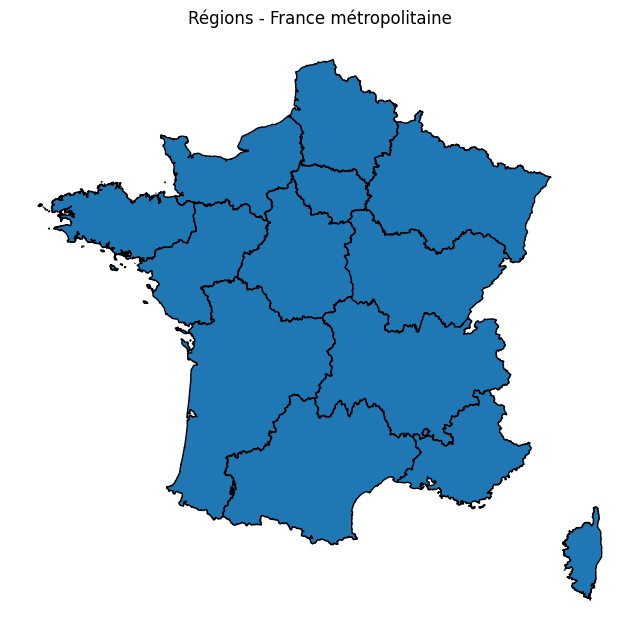

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf_regions = load_regions().copy()

# projection correcte
gdf_regions = gdf_regions.to_crs(epsg=4326)

# filtrer métropole (clé du problème)
gdf_regions_metro = gdf_regions.cx[-6:10, 41:52]

fig, ax = plt.subplots(figsize=(8, 8))
gdf_regions_metro.plot(ax=ax, edgecolor="black")
ax.set_title("Régions - France métropolitaine")
ax.axis("off")
plt.show()